In [1]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "Dolson30"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
   # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Comparative Experiments"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/Dolson30/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/Dolson30/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Comparative Experiments


# Homework 2: Randomized Block and Latin Square Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: October 3, 2025**

**PART 1 INSTRUCTIONS:** You are an educational researcher interested in comparing different methods for teaching data science to undergraduate students. There are three different methods you are interested in comparing: (1) Direct Instruction (traditional method); (2) Inquiry-Based Learning (teacher facilitates student problem solving); (3) Collaborative Learning (students working in small groups). To compare these methods, you decide to randomly recruit undergraduate data science students to be part of a workshop on hypothesis testing basics. Students will be randomly assigned to one of three workshops, where each workshop employs a different teaching method. At the end of the workshop, students will be given a 50-question quiz where their understanding of hypothesis testing will be assessed. Percentage scores on this quiz serve as the outcome of interest.

However, it would be apparent that the prior level of knowledge a student possess about hypothesis testing may serve as a potential confounding variable that you would want to control for. Thus, the Prior Knowledge a given student has about hypothesis testing is categorized into "High" and "Low". The data from this experiment are contained in the `Data Science Teaching Method.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

- The objective of this experiment is to compare the effectiveness of three different teaching methods on undergraduate data science students' understanding of hypothesis testing. The effectiveness is measured by the percentage score on a post-workshop quiz, while controlling for the potential confounding effect of students' prior knowledge (High or Low).

**Question 2.** Specify the outcome variable

- The outcome variable is the percentage score on the 50-question quiz that assesses the students' understanding of hypothesis testing.

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

- The independent variable (or treatment factor) is the Teaching Method.
- The blocking factor is Prior Knowledge.

Some possible lurking variables are:
-  Student Motivation/Interest
- A student's general intelligence, prior GPA, or overall quantitative skills could strongly influence how well they grasp the material.
- The number of hours a student dedicates to reviewing the workshop material outside of the session time.
- Learning Style: A student's inherent preferred learning style may happen to align better with one teaching method.
- Learning Environment/Time of Day

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

-  Randomized Block Design is appropriate because the researchers identified a nuisance factor—Prior Knowledge—that is known to influence the outcome.
 - By grouping students into blocks ("High" and "Low" prior knowledge) and then randomly assigning all three teaching methods within each block, the design removes the variability caused by prior knowledge from the error term. This makes the experiment more precise and increases the statistical power to detect a true difference among the teaching methods.

 - A Completely Randomized Design would be inappropriate because it ignores the known variation due to Prior Knowledge.

- One issue would be increased Error. In a CRD, students are randomly assigned to the three teaching methods without regard to their prior knowledge. The variation caused by the difference between high and low-knowledge students would be absorbed into the experimental error.

**Question 5.** State the null and alternative hypotheses for this experiment.

- Null Hypothesis: There is no significant difference in the true mean quiz scores among the three teaching methods.

- Alternative Hypothesis: At least one teaching method has a true mean quiz score that is significantly different from the others.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

- The results more strongly support the alternative hypothesis. The overall mean scores show a large jump from direct instruction to inquiry based and collaborative learning.


--- Q6: Summary Statistics (Mean, SD, and Count) ---
| Method        | Prior_Knowledge   |   N |   Mean_Score |   SD_Score |
|:--------------|:------------------|----:|-------------:|-----------:|
| Collaborative | High              |  10 |       90.927 |    7.97076 |
| Collaborative | Low               |  10 |       82.176 |    8.16879 |
| Direct        | High              |  10 |       76.998 |    6.1259  |
| Direct        | Low               |  10 |       73.659 |    6.62381 |
| Inquiry       | High              |  10 |       88.624 |    5.31684 |
| Inquiry       | Low               |  10 |       81.903 |    5.98439 |


/tmp/ipython-input-1674644604.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = teach.groupby(['Method', 'Prior_Knowledge'])['Score'].agg(


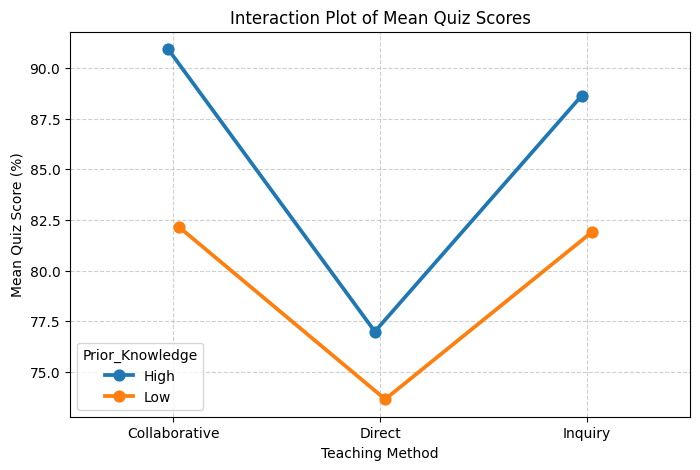

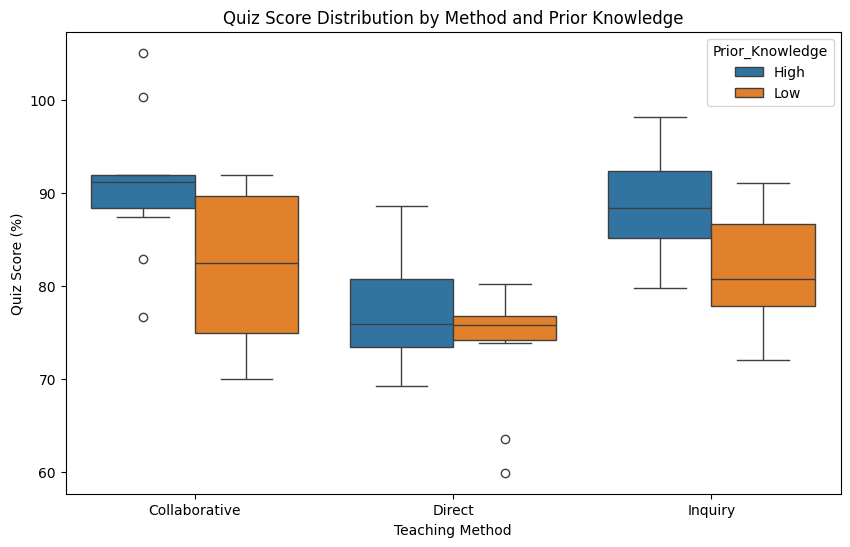

In [4]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## import the IPA Data and Get summary Stats ##
teach = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW2/Data Science Teaching Method.xlsx")
teach.columns = ['Prior_Knowledge', 'Method', 'Score']

# Convert the factors to categorical types for proper analysis
teach['Method'] = teach['Method'].astype('category')
teach['Prior_Knowledge'] = teach['Prior_Knowledge'].astype('category')

# -------------------------------------------------------------------
# 1. SUMMARY STATISTICS
# -------------------------------------------------------------------
print("--- Q6: Summary Statistics (Mean, SD, and Count) ---")
summary_stats = teach.groupby(['Method', 'Prior_Knowledge'])['Score'].agg(
    N='count',
    Mean_Score='mean',
    SD_Score='std'
).reset_index()

print(summary_stats.to_markdown(index=False))

# -------------------------------------------------------------------
# 2. DATA VISUALIZATIONS
# -------------------------------------------------------------------

# Interaction Plot (Means)
plt.figure(figsize=(8, 5))
sns.pointplot(data=teach, x='Method', y='Score', hue='Prior_Knowledge',
              dodge=True, errorbar=None, capsize=0.1)
plt.title('Interaction Plot of Mean Quiz Scores')
plt.ylabel('Mean Quiz Score (%)')
plt.xlabel('Teaching Method')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
#

# Grouped Boxplot (Distribution)
plt.figure(figsize=(10, 6))
sns.boxplot(data=teach, x='Method', y='Score', hue='Prior_Knowledge')
plt.title('Quiz Score Distribution by Method and Prior Knowledge')
plt.ylabel('Quiz Score (%)')
plt.xlabel('Teaching Method')
plt.show()
#

**Question 7**. Build a two-way ANOVA model. Test the assumption of normality using both a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

Question 8. Test the assumption of homogeneity of variance using both a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

Question 9. Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

Question 10. If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

Question 11. Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment.

PART 2 INSTRUCTIONS: Now suppose a university is evaluating the effectiveness of four different online learning platforms (say A, B, C, and D) on student engagement for students taking an undergraduate data science course in an online synchronous format. One section of the course is offered Monday through Thursday in the Morning, Early Afternoon, Mid-Afternoon, and Evening sections. Student engagement is measured through the total number of logins to the online learning platform for a given course section over the course of the semester. Below is a table describing the study design and factors:

Section \ Day	Monday	Tuesday	Wednesday	Thursday
Morning	A	B	C	D
Early Afternoon	B	C	D	A
Mid-Afternoon	C	D	A	B
Evening	D	A	B	C
Here, our main interest is in comparing engagement across the online learning platforms, but we also want to control for Day of the Week as well as Time of Day, as these could potentially be confounding variables. The data for this experiment are contained in the Online Learning and Engagement.xlsx file. With these data, your tasks are:

Question 1. Briefly define the objective of this experiment

Question 2. Specify the outcome variable

Question 3. Specify the independent variable and blocking factors. What are some other possible lurking variables?

Question 4. Briefly explain why a Latin Square Design would be appropriate here. Similarly, explain why a completely randomized design or randomized block design would not be appropriate.

Question 5. State the null and alternative hypotheses for this experiment.

Question 6. Perform appropriate exploratory analysis, including summary statistics and data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

Question 7. Build a three-way ANOVA model. Test the assumption of normality using both a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

Question 8. Test the assumption of homogeneity of variance using both a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

Question 9. Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

Question 10. If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

Question 11. Write a brief conclusion summarizing the results of your analyses, including potential limitations of this experiment.